# 2.1 Modelo Base Con NumPyro



Este notebook implementa el mismo modelo base del notebook 2.0, pero usando NumPyro con enumeracion de la variable discreta $b_s$.



El objetivo es que la formulacion del modelo sea facil de explicar y que los resultados queden guardados para compararlos en otro notebook.


## Modelo Generativo



Para cada estrella usamos:

$$
b_s \sim \mathrm{Categorical}(\mathbf f),
$$

$$
\hat{\varpi}_s \mid d_s \sim \mathcal N\left(1000/d_s, \sigma_{\hat{\varpi},s}^2\right),
$$

$$
\hat m_s \mid d_s, b_s \sim \mathcal N\left(\mu_{M,b_s} + 5\log_{10} d_s - 5,\ \sigma_{\hat m,s}^2 + \sigma_{M,b_s}^2\right),
$$

$$
\hat C_s \mid b_s \sim \mathcal N\left(\mu_{C,b_s},\ \sigma_{\hat C,s}^2 + \sigma_{C,b_s}^2\right).
$$

NumPyro enumera $b_s$ internamente, de modo que el modelo se escribe de forma generativa sin tener que codificar a mano el logsumexp.

In [1]:
from pathlib import Path

import warnings

import arviz as az
import blackjax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd

from jax import random
from jax.scipy.special import logsumexp
from numpyro.contrib.funsor import config_enumerate
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO, init_to_value
from numpyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from numpyro.infer.util import initialize_model
from numpyro.optim import Adam

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=UserWarning)

az.style.use("arviz-whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

In [2]:
ROOT = Path.cwd().resolve().parent
RAW_FILE = ROOT / "data" / "raw" / "GaiaQuery_804d220beb9e16594a86983e84d0cf43.ecsv"


def flux_to_mag_sigma(flux, flux_error):
    snr = np.asarray(flux) / np.asarray(flux_error)
    return 2.5 / np.log(10.0) / snr


def load_simulated_catalog(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, comment="#", sep=r"\s+")
    df.columns = [column.lower() for column in df.columns]

    required = [
        "source_id",
        "barycentric_distance",
        "parallax",
        "parallax_error",
        "phot_g_mean_mag",
        "phot_bp_mean_mag",
        "phot_rp_mean_mag",
        "phot_g_mean_flux",
        "phot_g_mean_flux_error",
        "phot_bp_mean_flux",
        "phot_bp_mean_flux_error",
        "phot_rp_mean_flux",
        "phot_rp_mean_flux_error",
        "mag_g",
        "mag_bp",
        "mag_rp",
    ]
    df = df.dropna(subset=required).copy()

    positive = (
        (df["barycentric_distance"] > 0)
        & (df["parallax_error"] > 0)
        & (df["phot_g_mean_flux"] > 0)
        & (df["phot_bp_mean_flux"] > 0)
        & (df["phot_rp_mean_flux"] > 0)
        & (df["phot_g_mean_flux_error"] > 0)
        & (df["phot_bp_mean_flux_error"] > 0)
        & (df["phot_rp_mean_flux_error"] > 0)
    )
    df = df.loc[positive].copy()

    df["color_obs"] = df["phot_bp_mean_mag"] - df["phot_rp_mean_mag"]
    df["sigma_g_mag"] = flux_to_mag_sigma(df["phot_g_mean_flux"], df["phot_g_mean_flux_error"])
    df["sigma_bp_mag"] = flux_to_mag_sigma(df["phot_bp_mean_flux"], df["phot_bp_mean_flux_error"])
    df["sigma_rp_mag"] = flux_to_mag_sigma(df["phot_rp_mean_flux"], df["phot_rp_mean_flux_error"])
    df["sigma_color"] = np.sqrt(df["sigma_bp_mag"] ** 2 + df["sigma_rp_mag"] ** 2)
    df["parallax_snr"] = df["parallax"] / df["parallax_error"]
    return df


def safe_distance_from_parallax(parallax_mas, floor_mas=0.2):
    clipped = np.clip(np.asarray(parallax_mas), floor_mas, None)
    return 1000.0 / clipped


def absolute_mag_from_distance(apparent_mag, distance_pc):
    return np.asarray(apparent_mag) - 5.0 * np.log10(np.asarray(distance_pc)) + 5.0


def plot_cmd(color, magnitude, *, ax=None, title="CMD observado", alpha=0.35, s=8):
    if ax is None:
        _, ax = plt.subplots()
    mask = np.isfinite(color) & np.isfinite(magnitude)
    ax.scatter(np.asarray(color)[mask], np.asarray(magnitude)[mask], s=s, alpha=alpha, edgecolors="none")
    ax.invert_yaxis()
    ax.set_xlabel("BP - RP")
    ax.set_ylabel(r"$M_G$")
    ax.set_title(title)
    return ax


catalog = load_simulated_catalog(RAW_FILE)
candidate_pool = catalog.loc[catalog["parallax_snr"] > 5].copy()
sample_size = min(30, len(candidate_pool))
sample = candidate_pool.sample(n=sample_size, random_state=42).sort_values("parallax_snr").reset_index(drop=True)

distance_point = safe_distance_from_parallax(sample["parallax"].to_numpy(), floor_mas=0.05)
sample["abs_mag_point"] = absolute_mag_from_distance(sample["phot_g_mean_mag"], distance_point)
sample["abs_mag_true"] = absolute_mag_from_distance(sample["mag_g"], sample["barycentric_distance"])

print(f"Estrellas disponibles con SNR > 5: {len(candidate_pool)}")
print(f"Tamano de la muestra usada: {sample_size}")

Estrellas disponibles con SNR > 5: 10
Tamano de la muestra usada: 10


<Axes: title={'center': 'CMD verdadero simulado'}, xlabel='BP - RP', ylabel='$M_G$'>

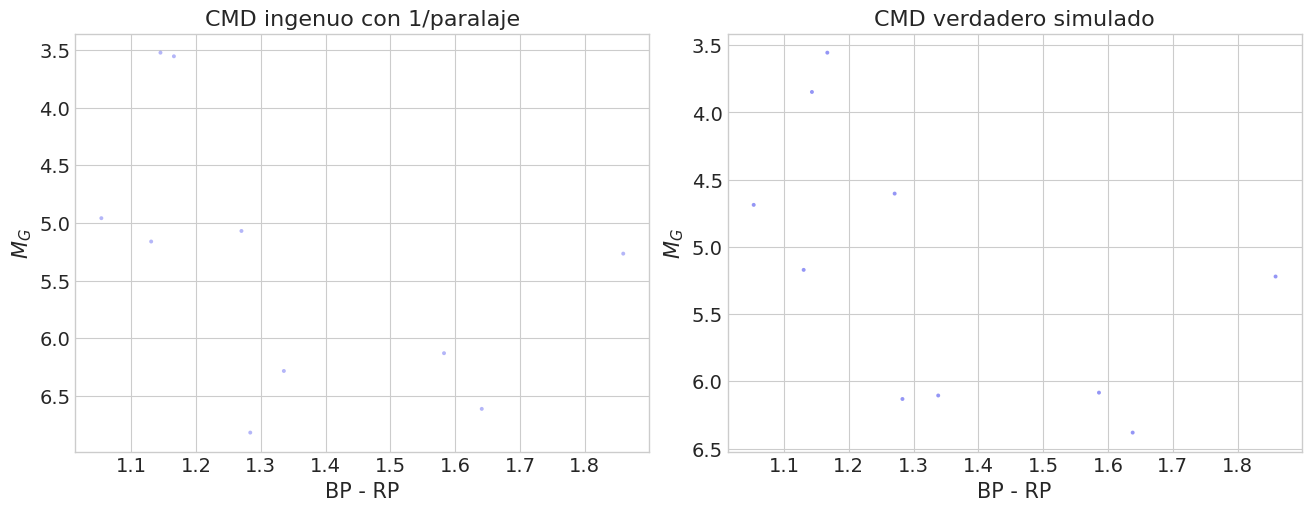

In [3]:
def build_cmd_grid(color_values, abs_mag_values, n_color=5, n_abs_mag=7, padding=0.15):
    color_lo, color_hi = np.quantile(color_values, [0.02, 0.98])
    abs_lo, abs_hi = np.quantile(abs_mag_values, [0.02, 0.98])
    color_edges = np.linspace(color_lo - padding, color_hi + padding, n_color + 1)
    abs_edges = np.linspace(abs_lo - padding, abs_hi + padding, n_abs_mag + 1)
    color_step = float(color_edges[1] - color_edges[0])
    abs_step = float(abs_edges[1] - abs_edges[0])
    color_centers = 0.5 * (color_edges[:-1] + color_edges[1:])
    abs_centers = 0.5 * (abs_edges[:-1] + abs_edges[1:])
    grid_color, grid_abs = np.meshgrid(color_centers, abs_centers, indexing="xy")
    return {
        "mu_color": grid_color.ravel(),
        "mu_abs_mag": grid_abs.ravel(),
        "sigma_color_kernel": np.full(grid_color.size, color_step),
        "sigma_abs_mag_kernel": np.full(grid_abs.size, abs_step),
        "shape": grid_abs.shape,
        "color_edges": color_edges,
        "abs_edges": abs_edges,
    }


def prepare_model_data(df: pd.DataFrame, grid: dict) -> dict:
    parallax = df["parallax"].to_numpy(dtype=float)
    parallax_error = df["parallax_error"].to_numpy(dtype=float)
    m_obs = df["phot_g_mean_mag"].to_numpy(dtype=float)
    sigma_m = df["sigma_g_mag"].to_numpy(dtype=float)
    color_obs = df["color_obs"].to_numpy(dtype=float)
    sigma_color = df["sigma_color"].to_numpy(dtype=float)
    distance_init = np.clip(1000.0 / np.clip(parallax, 0.05, None), 20.0, 6000.0)
    d_lower = np.clip(0.5 * distance_init, 10.0, None)
    d_upper = np.minimum(1.5 * distance_init, 7000.0)
    d_upper = np.maximum(d_upper, d_lower + 25.0)
    return {
        "parallax": parallax,
        "parallax_error": parallax_error,
        "m_obs": m_obs,
        "sigma_m": sigma_m,
        "color_obs": color_obs,
        "sigma_color": sigma_color,
        "distance_init": distance_init,
        "d_lower": d_lower,
        "d_upper": d_upper,
        **grid,
    }


grid = build_cmd_grid(sample["color_obs"], sample["abs_mag_point"], n_color=5, n_abs_mag=7)
model_data = prepare_model_data(sample, grid)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
plot_cmd(sample["color_obs"], sample["abs_mag_point"], ax=axes[0], title="CMD ingenuo con 1/paralaje")
plot_cmd(sample["mag_bp"] - sample["mag_rp"], sample["abs_mag_true"], ax=axes[1], title="CMD verdadero simulado", alpha=0.5)

In [ ]:
@config_enumerate
def numpyro_cmd_model(
    parallax,
    parallax_error,
    m_obs,
    sigma_m,
    color_obs,
    sigma_color,
    d_lower,
    d_upper,
    mu_abs_mag,
    mu_color,
    sigma_abs_mag_kernel,
    sigma_color_kernel,
 ):
    n_stars = parallax.shape[0]
    n_kernels = mu_abs_mag.shape[0]
    weights = numpyro.sample("weights", dist.Dirichlet(jnp.ones(n_kernels)))

    with numpyro.plate("star", n_stars):
        distance_pc = numpyro.sample("distance_pc", dist.Uniform(d_lower, d_upper))
        b = numpyro.sample("b", dist.Categorical(probs=weights))

        numpyro.sample("parallax_like", dist.Normal(1000.0 / distance_pc, parallax_error), obs=parallax)
        mu_m = mu_abs_mag[b] + 5.0 * jnp.log10(distance_pc) - 5.0
        sigma_m_total = jnp.sqrt(sigma_m**2 + sigma_abs_mag_kernel[b]**2)
        numpyro.sample("m_like", dist.Normal(mu_m, sigma_m_total), obs=m_obs)
        sigma_c_total = jnp.sqrt(sigma_color**2 + sigma_color_kernel[b]**2)
        numpyro.sample("c_like", dist.Normal(mu_color[b], sigma_c_total), obs=color_obs)


def numpyro_cmd_model_marginalized(
    parallax,
    parallax_error,
    m_obs,
    sigma_m,
    color_obs,
    sigma_color,
    d_lower,
    d_upper,
    mu_abs_mag,
    mu_color,
    sigma_abs_mag_kernel,
    sigma_color_kernel,
 ):
    n_stars = parallax.shape[0]
    n_kernels = mu_abs_mag.shape[0]
    weights = numpyro.sample("weights", dist.Dirichlet(jnp.ones(n_kernels)))

    with numpyro.plate("star", n_stars):
        distance_pc = numpyro.sample("distance_pc", dist.Uniform(d_lower, d_upper))

    log_parallax = dist.Normal(1000.0 / distance_pc, parallax_error).log_prob(parallax)
    mu_m = mu_abs_mag[None, :] + 5.0 * jnp.log10(distance_pc[:, None]) - 5.0
    sigma_m_total = jnp.sqrt(sigma_m[:, None] ** 2 + sigma_abs_mag_kernel[None, :] ** 2)
    sigma_c_total = jnp.sqrt(sigma_color[:, None] ** 2 + sigma_color_kernel[None, :] ** 2)

    log_cmd = logsumexp(
        jnp.log(weights)[None, :]
        + dist.Normal(mu_m, sigma_m_total).log_prob(m_obs[:, None])
        + dist.Normal(mu_color[None, :], sigma_c_total).log_prob(color_obs[:, None]),
        axis=-1,
    )

    numpyro.factor("obs_loglike", jnp.sum(log_parallax + log_cmd))


numpyro_example_inputs = {
    key: jnp.asarray(model_data[key])
    for key in [
        "parallax",
        "parallax_error",
        "m_obs",
        "sigma_m",
        "color_obs",
        "sigma_color",
        "d_lower",
        "d_upper",
        "mu_abs_mag",
        "mu_color",
        "sigma_abs_mag_kernel",
        "sigma_color_kernel",
    ]
}
sorted(numpyro_example_inputs)

['color_obs',
 'd_lower',
 'd_upper',
 'm_obs',
 'mu_abs_mag',
 'mu_color',
 'parallax',
 'parallax_error',
 'sigma_abs_mag_kernel',
 'sigma_color',
 'sigma_color_kernel',
 'sigma_m']

In [5]:
numpyro_init_values = {
    "weights": jnp.ones(model_data["mu_abs_mag"].size) / model_data["mu_abs_mag"].size,
    "distance_pc": jnp.asarray(model_data["distance_init"]),
}

numpyro_kernel = NUTS(
    numpyro_cmd_model,
    init_strategy=init_to_value(values=numpyro_init_values),
    target_accept_prob=0.92,
)

numpyro_mcmc = MCMC(
    numpyro_kernel,
    num_warmup=100,
    num_samples=100,
    num_chains=2,
    chain_method="sequential",
    progress_bar=True,
)

numpyro_mcmc.run(random.PRNGKey(42), **numpyro_example_inputs)
numpyro_samples = numpyro_mcmc.get_samples(group_by_chain=True)
numpyro_distance_mean = np.asarray(numpyro_samples["distance_pc"]).mean(axis=(0, 1))
numpyro_weights_mean = np.asarray(numpyro_samples["weights"]).mean(axis=(0, 1)).reshape(model_data["shape"])
numpyro_distance_mean[:5]

sample: 100%|██████████| 200/200 [00:00<00:00, 1149.44it/s, 15 steps of size 2.53e-01. acc. prob=0.94]


array([2794.80290018, 1696.73213962, 1985.78819661, 1370.97024445,
       1321.4085124 ])

## Modelo Marginalizado Estilo PyMC

Esta variante usa exactamente la misma idea algebraica que en PyMC: en lugar de muestrear la celda discreta $b_s$, integra su contribucion con un logsumexp.

Eso deja una likelihood marginalizada del CMD, mas suave para inferencia continua y especialmente util cuando queremos usar VI para explorar muestras mas grandes.

Aqui usamos una gaussiana multivariada en el espacio transformado de parametros como primera aproximacion variacional.

In [6]:
vi_init_values = {
    "weights": jnp.ones(model_data["mu_abs_mag"].size) / model_data["mu_abs_mag"].size,
    "distance_pc": jnp.asarray(model_data["distance_init"]),
}

vi_guide = AutoMultivariateNormal(
    numpyro_cmd_model_marginalized,
    init_loc_fn=init_to_value(values=vi_init_values),
)

vi = SVI(
    numpyro_cmd_model_marginalized,
    vi_guide,
    Adam(step_size=0.03),
    loss=Trace_ELBO(),
)

vi_rng_key = random.PRNGKey(2026)
vi_result = vi.run(
    vi_rng_key,
    3_000,
    progress_bar=True,
    **numpyro_example_inputs,
 )

vi_sample_key = random.PRNGKey(2027)
vi_samples = vi_guide.sample_posterior(
    vi_sample_key,
    vi_result.params,
    sample_shape=(4_000,),
    **numpyro_example_inputs,
 )

vi_distance_mean = np.asarray(vi_samples["distance_pc"]).mean(axis=0)
vi_weights_mean = np.asarray(vi_samples["weights"]).mean(axis=0).reshape(model_data["shape"])

float(vi_result.losses[-1]), vi_distance_mean[:5]

100%|██████████| 3000/3000 [00:02<00:00, 1440.80it/s, init loss: 82.5117, avg. loss [2851-3000]: 23.0713]


(25.236932907309573,
 array([2910.08506232, 1634.87074385, 1968.43250649, 1393.86395859,
        1306.12070324]))

In [7]:
marginal_nuts_init_values = {
    "weights": jnp.ones(model_data["mu_abs_mag"].size) / model_data["mu_abs_mag"].size,
    "distance_pc": jnp.asarray(model_data["distance_init"]),
}

marginal_nuts_kernel = NUTS(
    numpyro_cmd_model_marginalized,
    init_strategy=init_to_value(values=marginal_nuts_init_values),
    target_accept_prob=0.92,
 )

marginal_nuts_mcmc = MCMC(
    marginal_nuts_kernel,
    num_warmup=100,
    num_samples=100,
    num_chains=2,
    chain_method="sequential",
    progress_bar=True,
 )

marginal_nuts_mcmc.run(random.PRNGKey(2030), **numpyro_example_inputs)
marginal_nuts_samples = marginal_nuts_mcmc.get_samples(group_by_chain=True)
marginal_nuts_distance_mean = np.asarray(marginal_nuts_samples["distance_pc"]).mean(axis=(0, 1))
marginal_nuts_weights_mean = np.asarray(marginal_nuts_samples["weights"]).mean(axis=(0, 1)).reshape(model_data["shape"])

marginal_nuts_distance_mean[:5]

sample: 100%|██████████| 200/200 [00:00<00:00, 772.51it/s, 15 steps of size 2.28e-01. acc. prob=0.95]


array([2778.24577026, 1707.38995783, 1985.1719797 , 1395.93290958,
       1336.80314324])

## Modelo Con Asignacion Suave Tipo RelaxedOneHotCategorical

NumPyro 0.20.0 no expone `dist.RelaxedOneHotCategorical` con ese nombre, pero podemos construir la misma idea con una relajacion Gumbel-Softmax.
En el modelo discreto original, cada estrella elige una sola celda del CMD mediante una variable latente $b_s$. Eso produce una asignacion dura: toda la contribucion de la estrella cae en un unico componente de la mezcla.

La version relajada reemplaza esa eleccion puntual por un vector continuo $z_s = (z_{s1}, \dots, z_{sK})$ sobre el simplex, con $z_{sk} \ge 0$ y $\sum_k z_{sk} = 1$. Asi, cada estrella puede repartir masa entre varias celdas cercanas en lugar de seleccionar una sola.

La construccion es:

$$
g_{sk} \sim \mathrm{Gumbel}(0,1),
\qquad
z_{sk} = \frac{\exp\left((\log w_k + g_{sk}) / \tau\right)}{\sum_{j=1}^K \exp\left((\log w_j + g_{sj}) / \tau\right)},
$$

donde $w_k$ son los pesos globales de la mezcla y $\tau$ es la temperatura.

La temperatura controla cuan parecida es la relajacion a una categorica discreta:

- si $\tau$ es chica, $z_s$ se vuelve casi one-hot y el modelo se parece mas al caso discreto;
- si $\tau$ es grande, la asignacion es mas difusa y reparte probabilidad entre varias celdas.

Con ese vector suave definimos parametros efectivos por promedio ponderado:

$$
\mu_{M,s}^{\mathrm{soft}} = \sum_{k=1}^K z_{sk} \, \mu_{M,k},
\qquad
\mu_{C,s}^{\mathrm{soft}} = \sum_{k=1}^K z_{sk} \, \mu_{C,k},
$$

y de forma analoga combinamos las escalas intrinsecas del kernel.

Luego la likelihood queda completamente continua: la paralaje sigue dependiendo de $d_s$, mientras que magnitud y color usan esas medias y dispersiones suavizadas. Eso evita variables discretas explicitas y hace que el modelo sea mas amigable para VI y para optimizacion basada en gradientes.

La contracara es interpretativa: el modelo ya no representa "la estrella pertenece exactamente a una celda", sino "la estrella se parece en distinto grado a varias celdas del CMD". Por eso esta formulacion sirve mas como aproximacion continua util para inferencia rapida que como replica exacta del modelo discreto.

In [8]:
def numpyro_cmd_model_relaxed(
    parallax,
    parallax_error,
    m_obs,
    sigma_m,
    color_obs,
    sigma_color,
    d_lower,
    d_upper,
    mu_abs_mag,
    mu_color,
    sigma_abs_mag_kernel,
    sigma_color_kernel,
    temperature=0.35,
 ):
    n_stars = parallax.shape[0]
    n_kernels = mu_abs_mag.shape[0]
    weights = numpyro.sample("weights", dist.Dirichlet(jnp.ones(n_kernels)))
    log_weights = jnp.log(weights + 1e-12)

    with numpyro.plate("star", n_stars):
        distance_pc = numpyro.sample("distance_pc", dist.Uniform(d_lower, d_upper))
        gumbel_noise = numpyro.sample(
            "gumbel_noise",
            dist.Gumbel(0.0, 1.0).expand([n_kernels]).to_event(1),
        )
        z_soft = jax.nn.softmax((log_weights + gumbel_noise) / temperature, axis=-1)
        numpyro.deterministic("z_soft", z_soft)

        mu_abs_soft = jnp.sum(z_soft * mu_abs_mag, axis=-1)
        mu_color_soft = jnp.sum(z_soft * mu_color, axis=-1)
        sigma_abs_soft = jnp.sum(z_soft * sigma_abs_mag_kernel, axis=-1)
        sigma_color_soft = jnp.sum(z_soft * sigma_color_kernel, axis=-1)

        numpyro.sample("parallax_like", dist.Normal(1000.0 / distance_pc, parallax_error), obs=parallax)
        numpyro.sample(
            "m_like",
            dist.Normal(
                mu_abs_soft + 5.0 * jnp.log10(distance_pc) - 5.0,
                jnp.sqrt(sigma_m**2 + sigma_abs_soft**2),
            ),
            obs=m_obs,
        )
        numpyro.sample(
            "c_like",
            dist.Normal(mu_color_soft, jnp.sqrt(sigma_color**2 + sigma_color_soft**2)),
            obs=color_obs,
        )


relaxed_temperature = 0.35

relaxed_guide = AutoDiagonalNormal(numpyro_cmd_model_relaxed)
relaxed_vi = SVI(
    numpyro_cmd_model_relaxed,
    relaxed_guide,
    Adam(step_size=0.02),
    loss=Trace_ELBO(),
)

relaxed_rng_key = random.PRNGKey(2028)
relaxed_result = relaxed_vi.run(
    relaxed_rng_key,
    4_000,
    progress_bar=True,
    temperature=relaxed_temperature,
    **numpyro_example_inputs,
 )

relaxed_sample_key = random.PRNGKey(2029)
relaxed_samples = relaxed_guide.sample_posterior(
    relaxed_sample_key,
    relaxed_result.params,
    sample_shape=(4_000,),
    temperature=relaxed_temperature,
    **numpyro_example_inputs,
 )

relaxed_distance_mean = np.asarray(relaxed_samples["distance_pc"]).mean(axis=0)
relaxed_weights_mean = np.asarray(relaxed_samples["weights"]).mean(axis=0).reshape(model_data["shape"])

float(relaxed_result.losses[-1]), relaxed_distance_mean[:5]

100%|██████████| 4000/4000 [00:03<00:00, 1148.63it/s, init loss: 1208.4040, avg. loss [3801-4000]: 56.5216]


(74.5044905987282,
 array([2843.9562208 , 1706.95163616, 1983.02589572, 1480.05559696,
        1407.05157318]))

In [9]:
relaxed_nuts_init_values = {
    "weights": jnp.ones(model_data["mu_abs_mag"].size) / model_data["mu_abs_mag"].size,
    "distance_pc": jnp.asarray(model_data["distance_init"]),
    "gumbel_noise": jnp.zeros((sample_size, model_data["mu_abs_mag"].size)),
}

relaxed_nuts_kernel = NUTS(
    numpyro_cmd_model_relaxed,
    init_strategy=init_to_value(values=relaxed_nuts_init_values),
    target_accept_prob=0.92,
 )

relaxed_nuts_mcmc = MCMC(
    relaxed_nuts_kernel,
    num_warmup=100,
    num_samples=100,
    num_chains=2,
    chain_method="sequential",
    progress_bar=True,
 )

relaxed_nuts_mcmc.run(
    random.PRNGKey(2031),
    temperature=relaxed_temperature,
    **numpyro_example_inputs,
 )
relaxed_nuts_samples = relaxed_nuts_mcmc.get_samples(group_by_chain=True)
relaxed_nuts_distance_mean = np.asarray(relaxed_nuts_samples["distance_pc"]).mean(axis=(0, 1))
relaxed_nuts_weights_mean = np.asarray(relaxed_nuts_samples["weights"]).mean(axis=(0, 1)).reshape(model_data["shape"])

relaxed_nuts_distance_mean[:5]

sample: 100%|██████████| 200/200 [00:00<00:00, 357.95it/s, 63 steps of size 8.36e-02. acc. prob=0.96]


array([2780.37228169, 1714.6289061 , 1968.56143885, 1421.26583541,
       1373.59760116])

## Pathfinder Con BlackJAX



Antes de guardar resultados, construimos una aproximacion variacional del posterior con Pathfinder.



La idea sigue el tutorial oficial de NumPyro con BlackJAX:



1. extraer la funcion de energia potencial con initialize_model;

2. convertirla a una log-densidad en el espacio no restringido;

3. correr Pathfinder sobre esa log-densidad;

4. transformar las muestras al espacio original de parametros.



Aqui usamos Pathfinder como aproximacion rapida adicional y como referencia frente a NUTS.


In [ ]:
model_args = (
    numpyro_example_inputs["parallax"],
    numpyro_example_inputs["parallax_error"],
    numpyro_example_inputs["m_obs"],
    numpyro_example_inputs["sigma_m"],
    numpyro_example_inputs["color_obs"],
    numpyro_example_inputs["sigma_color"],
    numpyro_example_inputs["d_lower"],
    numpyro_example_inputs["d_upper"],
    numpyro_example_inputs["mu_abs_mag"],
    numpyro_example_inputs["mu_color"],
    numpyro_example_inputs["sigma_abs_mag_kernel"],
    numpyro_example_inputs["sigma_color_kernel"],
)

rng_key = random.PRNGKey(123)
rng_key, rng_subkey = random.split(rng_key)

param_info, potential_fn, postprocess_fn, *_ = initialize_model(
    rng_subkey,
    numpyro_cmd_model,
    model_args=model_args,
    dynamic_args=True,
)

initial_position = param_info.z

def logdensity_fn(position):
    return -potential_fn(*model_args)(position)

logdensity_fn(initial_position)

Array(-121.53424204, dtype=float64)

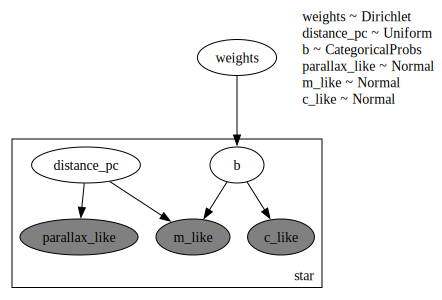

In [15]:
numpyro.render_model(numpyro_cmd_model, model_args=model_args, render_distributions=True)

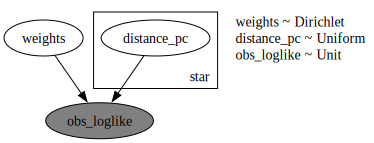

In [16]:
numpyro.render_model(numpyro_cmd_model_marginalized, model_args=model_args, render_distributions=True)

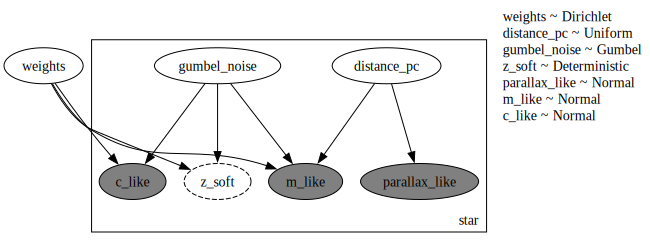

In [17]:
numpyro.render_model(numpyro_cmd_model_relaxed, model_args=model_args, render_distributions=True)

In [11]:
rng_key, rng_subkey = random.split(rng_key)
pathfinder_state, _ = blackjax.vi.pathfinder.approximate(
    rng_key=rng_subkey,
    logdensity_fn=logdensity_fn,
    initial_position=initial_position,
    num_samples=15_000,
    ftol=1e-4,
)


rng_key, rng_subkey = random.split(rng_key)
pathfinder_samples_unconstrained, _ = blackjax.vi.pathfinder.sample(
    rng_key=rng_subkey,
    state=pathfinder_state,
    num_samples=4_000,
)


pathfinder_postprocess = postprocess_fn(*model_args)
pathfinder_samples = jax.vmap(pathfinder_postprocess)(pathfinder_samples_unconstrained)

pathfinder_distance_mean = np.asarray(pathfinder_samples["distance_pc"]).mean(axis=0)
pathfinder_weights_mean = np.asarray(pathfinder_samples["weights"]).mean(axis=0).reshape(model_data["shape"])

pathfinder_distance_mean[:5]

array([2708.52505279, 1578.57054304, 1901.66320974, 1363.07374036,
       1209.3151343 ])

RMSE solo paralaje: 229.5 pc
RMSE NUTS enumerado: 194.2 pc
RMSE NUTS marginal: 184.9 pc
RMSE NUTS relajado: 178.5 pc
RMSE VI marginal: 215.3 pc
RMSE VI relajada: 196.6 pc
RMSE Pathfinder: 229.1 pc


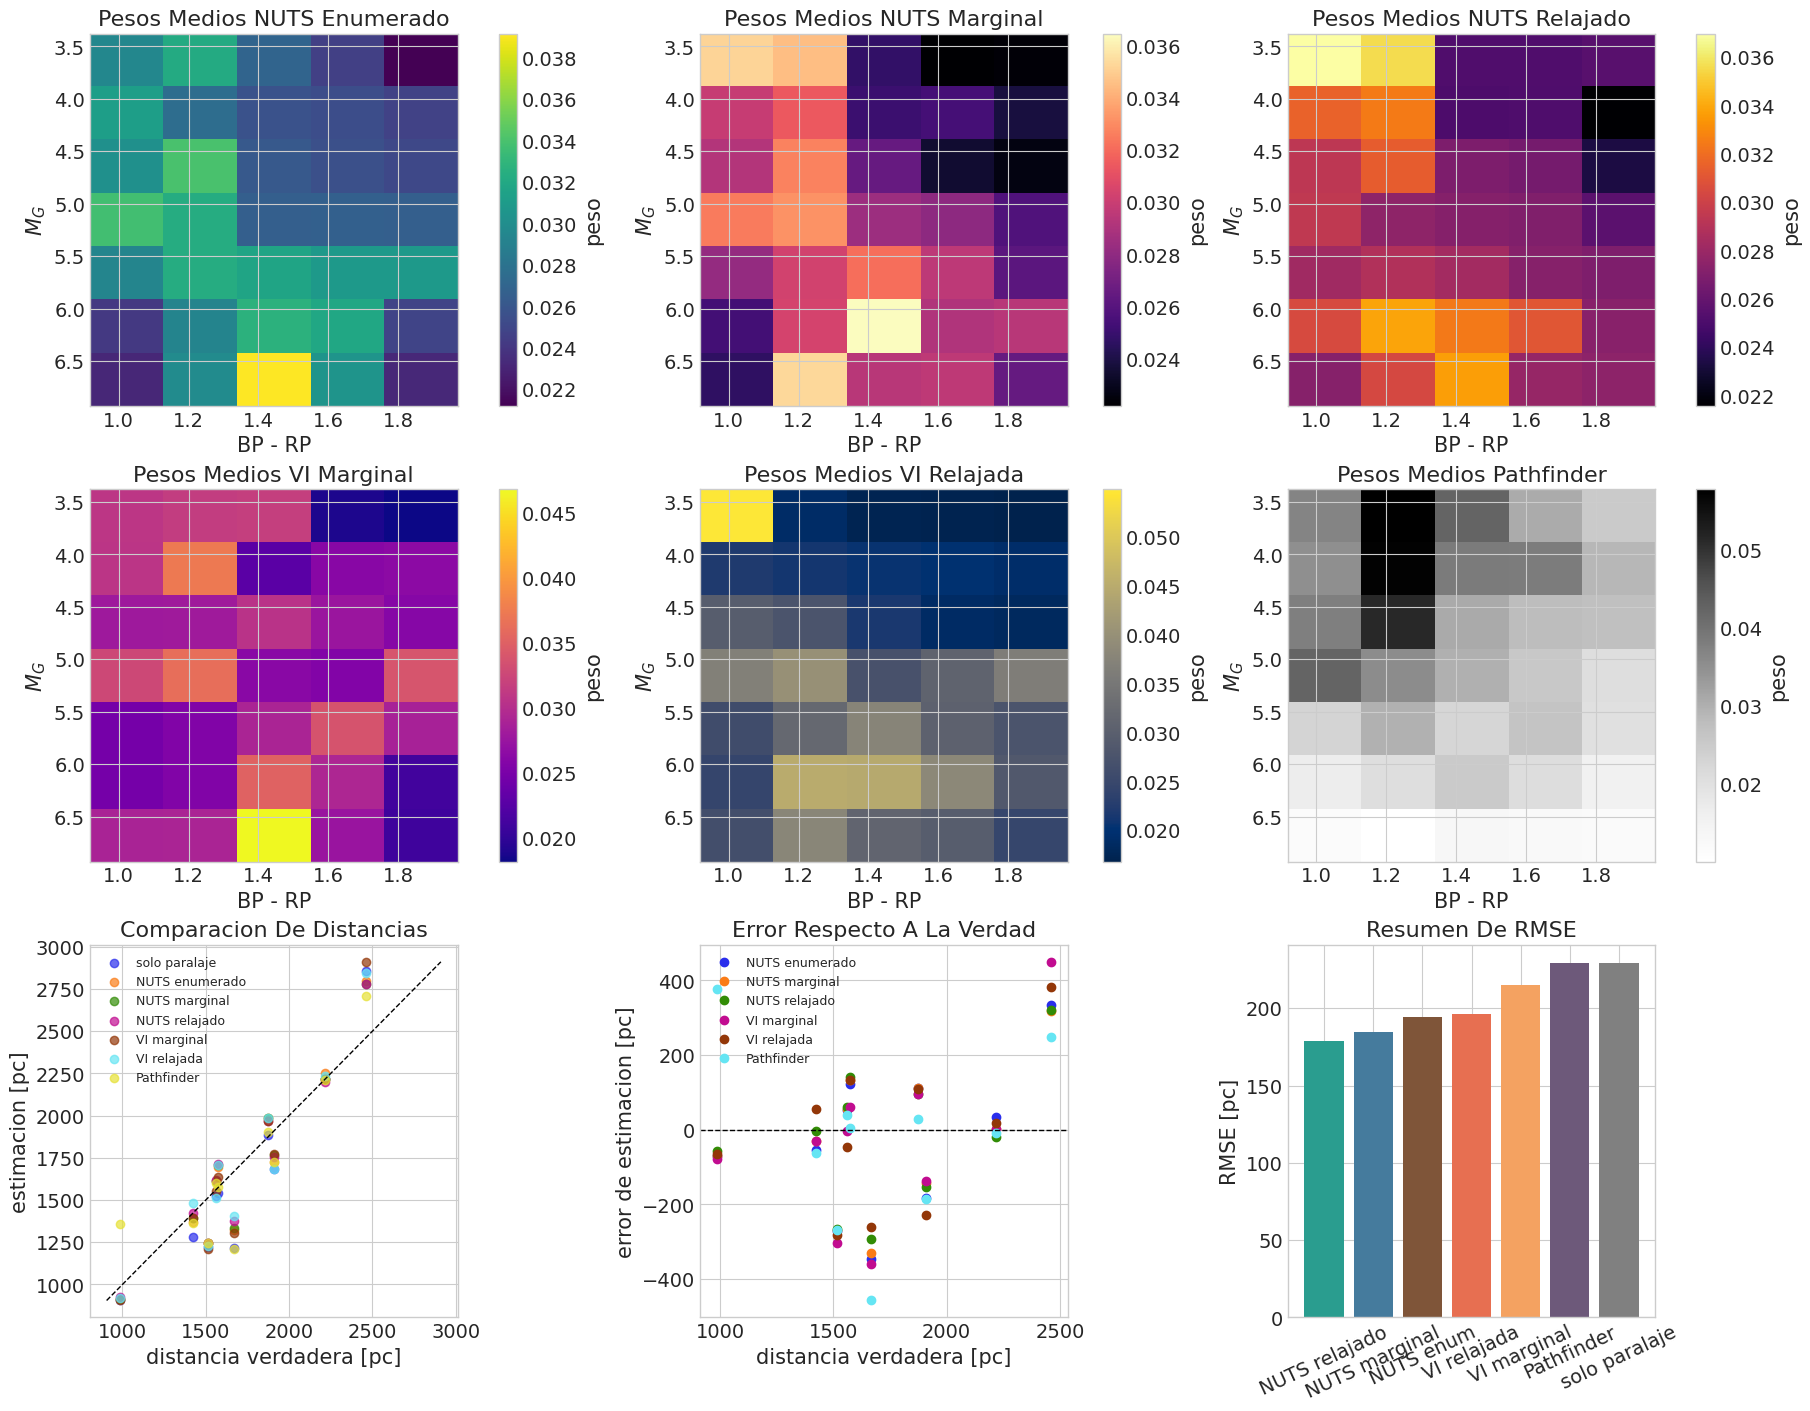

In [12]:
true_distance = sample["barycentric_distance"].to_numpy()
parallax_only = model_data["distance_init"]


def rmse(prediction, truth):
    return float(np.sqrt(np.mean((np.asarray(prediction) - np.asarray(truth)) ** 2)))


fig, axes = plt.subplots(3, 3, figsize=(18, 14), constrained_layout=True)
extent = [
    model_data["color_edges"][0],
    model_data["color_edges"][-1],
    model_data["abs_edges"][0],
    model_data["abs_edges"][-1],
]

image0 = axes[0, 0].imshow(
    numpyro_weights_mean,
    aspect="auto",
    origin="lower",
    extent=extent,
    cmap="viridis",
)
axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel("BP - RP")
axes[0, 0].set_ylabel(r"$M_G$")
axes[0, 0].set_title("Pesos Medios NUTS Enumerado")
fig.colorbar(image0, ax=axes[0, 0], label="peso")

image1 = axes[0, 1].imshow(
    marginal_nuts_weights_mean,
    aspect="auto",
    origin="lower",
    extent=extent,
    cmap="magma",
)
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel("BP - RP")
axes[0, 1].set_ylabel(r"$M_G$")
axes[0, 1].set_title("Pesos Medios NUTS Marginal")
fig.colorbar(image1, ax=axes[0, 1], label="peso")

image2 = axes[0, 2].imshow(
    relaxed_nuts_weights_mean,
    aspect="auto",
    origin="lower",
    extent=extent,
    cmap="inferno",
)
axes[0, 2].invert_yaxis()
axes[0, 2].set_xlabel("BP - RP")
axes[0, 2].set_ylabel(r"$M_G$")
axes[0, 2].set_title("Pesos Medios NUTS Relajado")
fig.colorbar(image2, ax=axes[0, 2], label="peso")

image3 = axes[1, 0].imshow(
    vi_weights_mean,
    aspect="auto",
    origin="lower",
    extent=extent,
    cmap="plasma",
)
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel("BP - RP")
axes[1, 0].set_ylabel(r"$M_G$")
axes[1, 0].set_title("Pesos Medios VI Marginal")
fig.colorbar(image3, ax=axes[1, 0], label="peso")

image4 = axes[1, 1].imshow(
    relaxed_weights_mean,
    aspect="auto",
    origin="lower",
    extent=extent,
    cmap="cividis",
)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel("BP - RP")
axes[1, 1].set_ylabel(r"$M_G$")
axes[1, 1].set_title("Pesos Medios VI Relajada")
fig.colorbar(image4, ax=axes[1, 1], label="peso")

image5 = axes[1, 2].imshow(
    pathfinder_weights_mean,
    aspect="auto",
    origin="lower",
    extent=extent,
    cmap="Greys",
)
axes[1, 2].invert_yaxis()
axes[1, 2].set_xlabel("BP - RP")
axes[1, 2].set_ylabel(r"$M_G$")
axes[1, 2].set_title("Pesos Medios Pathfinder")
fig.colorbar(image5, ax=axes[1, 2], label="peso")

limits = [
    min(
        true_distance.min(),
        parallax_only.min(),
        numpyro_distance_mean.min(),
        marginal_nuts_distance_mean.min(),
        relaxed_nuts_distance_mean.min(),
        vi_distance_mean.min(),
        relaxed_distance_mean.min(),
        pathfinder_distance_mean.min(),
    ),
    max(
        true_distance.max(),
        parallax_only.max(),
        numpyro_distance_mean.max(),
        marginal_nuts_distance_mean.max(),
        relaxed_nuts_distance_mean.max(),
        vi_distance_mean.max(),
        relaxed_distance_mean.max(),
        pathfinder_distance_mean.max(),
    ),
]

axes[2, 0].scatter(true_distance, parallax_only, alpha=0.7, label="solo paralaje")
axes[2, 0].scatter(true_distance, numpyro_distance_mean, alpha=0.7, label="NUTS enumerado")
axes[2, 0].scatter(true_distance, marginal_nuts_distance_mean, alpha=0.7, label="NUTS marginal")
axes[2, 0].scatter(true_distance, relaxed_nuts_distance_mean, alpha=0.7, label="NUTS relajado")
axes[2, 0].scatter(true_distance, vi_distance_mean, alpha=0.7, label="VI marginal")
axes[2, 0].scatter(true_distance, relaxed_distance_mean, alpha=0.7, label="VI relajada")
axes[2, 0].scatter(true_distance, pathfinder_distance_mean, alpha=0.7, label="Pathfinder")
axes[2, 0].plot(limits, limits, linestyle="--", color="black", linewidth=1)
axes[2, 0].set_xlabel("distancia verdadera [pc]")
axes[2, 0].set_ylabel("estimacion [pc]")
axes[2, 0].set_title("Comparacion De Distancias")
axes[2, 0].legend(fontsize=9)

axes[2, 1].plot(true_distance, numpyro_distance_mean - true_distance, "o", label="NUTS enumerado")
axes[2, 1].plot(true_distance, marginal_nuts_distance_mean - true_distance, "o", label="NUTS marginal")
axes[2, 1].plot(true_distance, relaxed_nuts_distance_mean - true_distance, "o", label="NUTS relajado")
axes[2, 1].plot(true_distance, vi_distance_mean - true_distance, "o", label="VI marginal")
axes[2, 1].plot(true_distance, relaxed_distance_mean - true_distance, "o", label="VI relajada")
axes[2, 1].plot(true_distance, pathfinder_distance_mean - true_distance, "o", label="Pathfinder")
axes[2, 1].axhline(0.0, linestyle="--", color="black", linewidth=1)
axes[2, 1].set_xlabel("distancia verdadera [pc]")
axes[2, 1].set_ylabel("error de estimacion [pc]")
axes[2, 1].set_title("Error Respecto A La Verdad")
axes[2, 1].legend(fontsize=9)

rmse_table = pd.Series(
    {
        "solo paralaje": rmse(parallax_only, true_distance),
        "NUTS enum": rmse(numpyro_distance_mean, true_distance),
        "NUTS marginal": rmse(marginal_nuts_distance_mean, true_distance),
        "NUTS relajado": rmse(relaxed_nuts_distance_mean, true_distance),
        "VI marginal": rmse(vi_distance_mean, true_distance),
        "VI relajada": rmse(relaxed_distance_mean, true_distance),
        "Pathfinder": rmse(pathfinder_distance_mean, true_distance),
    }
).sort_values()

axes[2, 2].bar(
    rmse_table.index,
    rmse_table.values,
    color=["#2a9d8f", "#457b9d", "#7f5539", "#e76f51", "#f4a261", "#6d597a", "0.5"],
)
axes[2, 2].set_ylabel("RMSE [pc]")
axes[2, 2].set_title("Resumen De RMSE")
axes[2, 2].tick_params(axis="x", rotation=25)

print(f"RMSE solo paralaje: {rmse(parallax_only, true_distance):.1f} pc")
print(f"RMSE NUTS enumerado: {rmse(numpyro_distance_mean, true_distance):.1f} pc")
print(f"RMSE NUTS marginal: {rmse(marginal_nuts_distance_mean, true_distance):.1f} pc")
print(f"RMSE NUTS relajado: {rmse(relaxed_nuts_distance_mean, true_distance):.1f} pc")
print(f"RMSE VI marginal: {rmse(vi_distance_mean, true_distance):.1f} pc")
print(f"RMSE VI relajada: {rmse(relaxed_distance_mean, true_distance):.1f} pc")
print(f"RMSE Pathfinder: {rmse(pathfinder_distance_mean, true_distance):.1f} pc")

## Guardar Resultados

Se guardan seis conjuntos de artefactos en models/:

- NUTS con enumeracion discreta;
- NUTS sobre el modelo marginalizado estilo PyMC;
- NUTS sobre el modelo relajado con asignacion suave;
- VI marginalizada con la misma algebra que PyMC;
- VI con asignacion suave tipo Gumbel-Softmax;
- Pathfinder como aproximacion local adicional.

Cada metodo guarda un archivo NetCDF con muestras y un NPZ con arreglos listos para comparacion.

In [13]:
RESULTS_DIR = ROOT / "models"
RESULTS_DIR.mkdir(exist_ok=True)

NUMPYRO_IDATA_PATH = RESULTS_DIR / "numpyro_base_model_tuned.nc"
NUMPYRO_RESULTS_PATH = RESULTS_DIR / "numpyro_base_model_tuned_results.npz"
MARGINAL_NUTS_IDATA_PATH = RESULTS_DIR / "numpyro_marginal_nuts_model.nc"
MARGINAL_NUTS_RESULTS_PATH = RESULTS_DIR / "numpyro_marginal_nuts_model_results.npz"
VI_IDATA_PATH = RESULTS_DIR / "numpyro_vi_model.nc"
VI_RESULTS_PATH = RESULTS_DIR / "numpyro_vi_model_results.npz"
RELAXED_NUTS_IDATA_PATH = RESULTS_DIR / "numpyro_relaxed_nuts_model.nc"
RELAXED_NUTS_RESULTS_PATH = RESULTS_DIR / "numpyro_relaxed_nuts_model_results.npz"
RELAXED_IDATA_PATH = RESULTS_DIR / "numpyro_relaxed_model.nc"
RELAXED_RESULTS_PATH = RESULTS_DIR / "numpyro_relaxed_model_results.npz"
PATHFINDER_IDATA_PATH = RESULTS_DIR / "numpyro_pathfinder.nc"
PATHFINDER_RESULTS_PATH = RESULTS_DIR / "numpyro_pathfinder_results.npz"

for handle_name in [
    "numpyro_idata",
    "marginal_nuts_idata",
    "vi_idata",
    "relaxed_nuts_idata",
    "relaxed_idata",
    "pathfinder_idata",
]:
    handle = globals().get(handle_name)
    if hasattr(handle, "close"):
        try:
            handle.close()
        except Exception:
            pass

for output_path in [
    NUMPYRO_IDATA_PATH,
    NUMPYRO_RESULTS_PATH,
    MARGINAL_NUTS_IDATA_PATH,
    MARGINAL_NUTS_RESULTS_PATH,
    VI_IDATA_PATH,
    VI_RESULTS_PATH,
    RELAXED_NUTS_IDATA_PATH,
    RELAXED_NUTS_RESULTS_PATH,
    RELAXED_IDATA_PATH,
    RELAXED_RESULTS_PATH,
    PATHFINDER_IDATA_PATH,
    PATHFINDER_RESULTS_PATH,
]:
    if output_path.exists():
        output_path.unlink()

numpyro_idata = az.from_dict(
    posterior={
        "distance_pc": np.asarray(numpyro_samples["distance_pc"]),
        "weights": np.asarray(numpyro_samples["weights"]),
    },
    coords={"star": np.arange(sample_size), "kernel": np.arange(model_data["mu_abs_mag"].size)},
    dims={"distance_pc": ["star"], "weights": ["kernel"]},
)

marginal_nuts_idata = az.from_dict(
    posterior={
        "distance_pc": np.asarray(marginal_nuts_samples["distance_pc"]),
        "weights": np.asarray(marginal_nuts_samples["weights"]),
    },
    coords={"star": np.arange(sample_size), "kernel": np.arange(model_data["mu_abs_mag"].size)},
    dims={"distance_pc": ["star"], "weights": ["kernel"]},
)

vi_idata = az.from_dict(
    posterior={
        "distance_pc": np.asarray(vi_samples["distance_pc"])[None, ...],
        "weights": np.asarray(vi_samples["weights"])[None, ...],
    },
    coords={"star": np.arange(sample_size), "kernel": np.arange(model_data["mu_abs_mag"].size)},
    dims={"distance_pc": ["star"], "weights": ["kernel"]},
)

relaxed_nuts_idata = az.from_dict(
    posterior={
        "distance_pc": np.asarray(relaxed_nuts_samples["distance_pc"]),
        "weights": np.asarray(relaxed_nuts_samples["weights"]),
    },
    coords={"star": np.arange(sample_size), "kernel": np.arange(model_data["mu_abs_mag"].size)},
    dims={"distance_pc": ["star"], "weights": ["kernel"]},
)

relaxed_idata = az.from_dict(
    posterior={
        "distance_pc": np.asarray(relaxed_samples["distance_pc"])[None, ...],
        "weights": np.asarray(relaxed_samples["weights"])[None, ...],
    },
    coords={"star": np.arange(sample_size), "kernel": np.arange(model_data["mu_abs_mag"].size)},
    dims={"distance_pc": ["star"], "weights": ["kernel"]},
)

pathfinder_idata = az.from_dict(
    posterior={
        "distance_pc": np.asarray(pathfinder_samples["distance_pc"])[None, ...],
        "weights": np.asarray(pathfinder_samples["weights"])[None, ...],
    },
    coords={"star": np.arange(sample_size), "kernel": np.arange(model_data["mu_abs_mag"].size)},
    dims={"distance_pc": ["star"], "weights": ["kernel"]},
)

numpyro_idata.to_netcdf(NUMPYRO_IDATA_PATH)
marginal_nuts_idata.to_netcdf(MARGINAL_NUTS_IDATA_PATH)
vi_idata.to_netcdf(VI_IDATA_PATH)
relaxed_nuts_idata.to_netcdf(RELAXED_NUTS_IDATA_PATH)
relaxed_idata.to_netcdf(RELAXED_IDATA_PATH)
pathfinder_idata.to_netcdf(PATHFINDER_IDATA_PATH)

np.savez(
    NUMPYRO_RESULTS_PATH,
    posterior_distance=numpyro_distance_mean,
    posterior_weights=numpyro_weights_mean,
    true_distance=true_distance,
    parallax_only=parallax_only,
    color_edges=model_data["color_edges"],
    abs_edges=model_data["abs_edges"],
    sample_source_id=sample["source_id"].to_numpy(),
    rmse=rmse(numpyro_distance_mean, true_distance),
)

np.savez(
    MARGINAL_NUTS_RESULTS_PATH,
    posterior_distance=marginal_nuts_distance_mean,
    posterior_weights=marginal_nuts_weights_mean,
    true_distance=true_distance,
    parallax_only=parallax_only,
    color_edges=model_data["color_edges"],
    abs_edges=model_data["abs_edges"],
    sample_source_id=sample["source_id"].to_numpy(),
    rmse=rmse(marginal_nuts_distance_mean, true_distance),
)

np.savez(
    VI_RESULTS_PATH,
    posterior_distance=vi_distance_mean,
    posterior_weights=vi_weights_mean,
    true_distance=true_distance,
    parallax_only=parallax_only,
    color_edges=model_data["color_edges"],
    abs_edges=model_data["abs_edges"],
    sample_source_id=sample["source_id"].to_numpy(),
    rmse=rmse(vi_distance_mean, true_distance),
    final_loss=float(vi_result.losses[-1]),
)

np.savez(
    RELAXED_NUTS_RESULTS_PATH,
    posterior_distance=relaxed_nuts_distance_mean,
    posterior_weights=relaxed_nuts_weights_mean,
    true_distance=true_distance,
    parallax_only=parallax_only,
    color_edges=model_data["color_edges"],
    abs_edges=model_data["abs_edges"],
    sample_source_id=sample["source_id"].to_numpy(),
    rmse=rmse(relaxed_nuts_distance_mean, true_distance),
    temperature=relaxed_temperature,
)

np.savez(
    RELAXED_RESULTS_PATH,
    posterior_distance=relaxed_distance_mean,
    posterior_weights=relaxed_weights_mean,
    true_distance=true_distance,
    parallax_only=parallax_only,
    color_edges=model_data["color_edges"],
    abs_edges=model_data["abs_edges"],
    sample_source_id=sample["source_id"].to_numpy(),
    rmse=rmse(relaxed_distance_mean, true_distance),
    final_loss=float(relaxed_result.losses[-1]),
    temperature=relaxed_temperature,
)

np.savez(
    PATHFINDER_RESULTS_PATH,
    posterior_distance=pathfinder_distance_mean,
    posterior_weights=pathfinder_weights_mean,
    true_distance=true_distance,
    parallax_only=parallax_only,
    color_edges=model_data["color_edges"],
    abs_edges=model_data["abs_edges"],
    sample_source_id=sample["source_id"].to_numpy(),
    rmse=rmse(pathfinder_distance_mean, true_distance),
)

print(f"Posterior NumPyro NUTS guardado en: {NUMPYRO_IDATA_PATH}")
print(f"Resumen NumPyro NUTS guardado en: {NUMPYRO_RESULTS_PATH}")
print(f"Posterior NumPyro NUTS marginal guardado en: {MARGINAL_NUTS_IDATA_PATH}")
print(f"Resumen NumPyro NUTS marginal guardado en: {MARGINAL_NUTS_RESULTS_PATH}")
print(f"Posterior NumPyro VI marginal guardado en: {VI_IDATA_PATH}")
print(f"Resumen NumPyro VI marginal guardado en: {VI_RESULTS_PATH}")
print(f"Posterior NumPyro NUTS relajado guardado en: {RELAXED_NUTS_IDATA_PATH}")
print(f"Resumen NumPyro NUTS relajado guardado en: {RELAXED_NUTS_RESULTS_PATH}")
print(f"Posterior NumPyro VI relajada guardado en: {RELAXED_IDATA_PATH}")
print(f"Resumen NumPyro VI relajada guardado en: {RELAXED_RESULTS_PATH}")
print(f"Posterior Pathfinder guardado en: {PATHFINDER_IDATA_PATH}")
print(f"Resumen Pathfinder guardado en: {PATHFINDER_RESULTS_PATH}")

Posterior NumPyro NUTS guardado en: /var/home/isaac/projects/estimacion-paralajes/models/numpyro_base_model_tuned.nc
Resumen NumPyro NUTS guardado en: /var/home/isaac/projects/estimacion-paralajes/models/numpyro_base_model_tuned_results.npz
Posterior NumPyro NUTS marginal guardado en: /var/home/isaac/projects/estimacion-paralajes/models/numpyro_marginal_nuts_model.nc
Resumen NumPyro NUTS marginal guardado en: /var/home/isaac/projects/estimacion-paralajes/models/numpyro_marginal_nuts_model_results.npz
Posterior NumPyro VI marginal guardado en: /var/home/isaac/projects/estimacion-paralajes/models/numpyro_vi_model.nc
Resumen NumPyro VI marginal guardado en: /var/home/isaac/projects/estimacion-paralajes/models/numpyro_vi_model_results.npz
Posterior NumPyro NUTS relajado guardado en: /var/home/isaac/projects/estimacion-paralajes/models/numpyro_relaxed_nuts_model.nc
Resumen NumPyro NUTS relajado guardado en: /var/home/isaac/projects/estimacion-paralajes/models/numpyro_relaxed_nuts_model_resu